# Exercise — Fix the Impurities, Don't Drop Them

`loan_prediction_dataset.csv` (same file as the main notebook) arrives with real messiness:
missing values in several columns, and inconsistent text casing (`"yes"` vs `"Yes"`, `"urban"` vs `"Urban"`).

The lazy fix is `df.dropna()`. **Don't do that.** In this exercise you'll prove *why* it's lazy,
then build the correct pipeline: fix casing, impute properly (train-only, no leakage), and confirm
you kept every row.

### Rules
- No `dropna()` anywhere in your final pipeline.
- Anything you fit (imputers, encoders) must be fit on the **train** split only.
- By the end, `X_train`/`X_test` should have **zero** missing values and the **same row counts**
  as right after the split.


### Step 1. Import `numpy`, `pandas`, `train_test_split`, `SimpleImputer`, and `DecisionTreeClassifier` + `accuracy_score`.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

### Step 2. Load `loan_prediction_dataset.csv` into `df`. Print its shape, and print `df.isna().sum()` to see exactly which columns are dirty.

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/Laxminarayen/InceptezGenAI-Batch26/refs/heads/main/25.%20Decision%20Tree%20Handson%20-%20Regression/loan_prediction_dataset.csv")
print(df.shape)
print(df.isna().sum())

(614, 13)
Loan_ID               0
Gender               12
Married               4
Dependents           15
Education             0
Self_Employed        31
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64


### Step 3. The "just drop it" gut-check

Before fixing anything, measure the cost of the lazy approach:
- Compute `dropped = df.dropna()`. Print how many rows survive, and what **percentage** of the
  dataset that drops.
- Compare the approval rate (`Loan_Status == 'Y'`) **among the rows that would be dropped** vs.
  **among the rows that would survive**. Are they the same?

This tells you whether the missingness is random (safe-ish to drop) or biased (dropping would
skew your training data). Print both rates.


In [16]:
df['Credit_History'].value_counts()

,count
Credit_History,
1.0,485
0.0,80


In [18]:
df['Loan_Status'].value_counts()['Y']

np.int64(486)

In [ ]:
#IF null value is present "Y" - Drop Rows
#IF null values is present "X"

In [19]:
dropped = df.dropna()
print(df.shape[0])
print(dropped.shape[0])
print(dropped.shape[0]/df.shape[0])
print(df['Loan_Status'].value_counts())
print(dropped['Loan_Status'].value_counts())

#lost_rows = df.loc[df.index.difference(dropped.index)]
#print(df['Loan_Status'].value_counts())
#print(dropped['Loan_Status'].value_counts())
print(f"proportions dropped for approval: {dropped['Loan_Status'].value_counts()['Y']/df['Loan_Status'].value_counts()['Y']}")
print(f"proportions dropped for rejection: {dropped['Loan_Status'].value_counts()['N']/df['Loan_Status'].value_counts()['N']}")

614
475
0.7736156351791531
Loan_Status
Y    486
N    128
Name: count, dtype: int64
Loan_Status
Y    379
N     96
Name: count, dtype: int64
proportions dropped for approval: 0.779835390946502
proportions dropped for rejection: 0.75


### Step 4. Fix inconsistent casing

`Married`, `Self_Employed`, and `Property_Area` all contain mixed casing (`"yes"`, `"YES"`,
`"urban"`, ...). Strip whitespace and convert to title case for these three columns. Watch out —
`.str.title()` on a `NaN` produces the string `'Nan'`; convert that back to a real `np.nan`.

Print the sorted unique values of all three columns afterward to confirm they're clean.


In [4]:
df['Married'].value_counts()

,count
Married,
Yes,369
No,238
yes,3


In [5]:
df['Self_Employed'].value_counts()

,count
Self_Employed,
No,489
Yes,91
NO,3


In [6]:
df['Property_Area'].value_counts()

,count
Property_Area,
Semiurban,240
Urban,230
Rural,142
semiurban,1
urban,1


In [7]:
str("laxmi").title()

'Laxmi'

In [13]:
str(" laxmi ").strip()

'laxmi'

In [9]:
for col in ['Married', 'Self_Employed', 'Property_Area']:
    df[col] = df[col].str.strip().str.title()
    df.loc[df[col] == "Nan", col] = np.nan

print(df['Married'].value_counts())
print(df['Self_Employed'].value_counts())
print(df['Property_Area'].value_counts())

Married
Yes    372
No     238
Name: count, dtype: int64
Self_Employed
No     492
Yes     91
Name: count, dtype: int64
Property_Area
Semiurban    241
Urban        231
Rural        142
Name: count, dtype: int64


In [22]:
df['Credit_History'] = df['Credit_History'].apply(lambda x: 0.0 if np.isnan(x) else x)

In [23]:
df['Credit_History'].value_counts()

,count
Credit_History,
1.0,485
0.0,129


In [ ]:
df.isna().sum()

### Step 5. Split BEFORE you impute

Build `X` from these columns:
```
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
```
and `y` as `Loan_Status == 'Y'` (as int).

Split into `X_train`, `X_test`, `y_train`, `y_test` with `test_size=0.2`, `random_state=42`,
`stratify=y`.

**Why split before imputing?** Write a one-line comment answering this in your own words.


In [25]:
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

X = df[num_cols + cat_cols]
y = (df['Loan_Status'] == 'Y').astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) #80-Train / 20-Test
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(491, 11)
(123, 11)
(491,)
(123,)


In [28]:
(df['Loan_Status'] == 'Y').astype(int)

,Loan_Status
0,0
1,0
2,1
3,1
4,1
...,...
609,1
610,1
611,1
612,1


### Step 6. Fix (impute) the numeric columns — don't drop them

Fit a `SimpleImputer(strategy='median')` on `X_train[num_cols]` only. Transform both
`X_train[num_cols]` and `X_test[num_cols]` with the fitted imputer (never re-fit on test).


In [30]:
#num_imputer - is the imputer function
num_imputer = SimpleImputer(strategy='median') #imputing missing
num_imputer #This is just empty defenition

SimpleImputer(strategy='median')

In [ ]:
num_imputer.fit()
num_imputer.fit_transform()
num_imputer.transform()

In [31]:
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols]) #fit on train - Median is computed only on the train and is stored in the empty defenition

In [35]:
num_imputer.feature_names_in_

array(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'], dtype=object)

In [34]:
print(num_imputer.statistics_)


[6.556e+03 6.610e+02 8.900e+01 3.600e+02 1.000e+00]


In [29]:
X_test[num_cols] = num_imputer.transform(X_test[num_cols]) #missing values of the test - Median found from train train data is replaced

### Step 7. Fix (impute) the categorical columns

Same idea, `SimpleImputer(strategy='most_frequent')`, fit on `X_train[cat_cols]` only, applied to
both splits.


In [36]:
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

### Step 8. Prove you fixed it instead of dropping it

Print:
- `X_train.isna().sum().sum()` and `X_test.isna().sum().sum()` — should both be `0`.
- `len(X_train)` and `len(X_test)` — compare them to the row counts right after Step 5's split.
  They should be **identical** (no rows lost).


In [37]:
X_train.isna().sum().sum()

np.int64(0)

In [38]:
X_test.isna().sum().sum()

np.int64(0)

### Step 9. One-hot encode

`pd.get_dummies` the categorical columns for train and test. Reindex the test matrix to match the
train matrix's columns (`fill_value=0`) so both have identical columns in identical order.


In [ ]:
X_train

In [40]:
X_train_enc = pd.get_dummies(X_train, columns = cat_cols)
X_test_enc = pd.get_dummies(X_test, columns = cat_cols)
X_test_enc = X_test_enc.reindex(columns = X_train_enc.columns, fill_value=0)

### Step 10 (stretch). Fixed data vs. dropped data — does it matter?

Train two `DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)` models:

1. On your **fixed** `X_train_enc` / `y_train` from Step 9, evaluated on your fixed test set.
2. On a version built by `dropna()`-ing the raw `df` first, then splitting/encoding the same way.

Print both test accuracies and both test set sizes side by side. This is your evidence for why
fixing beats dropping — you keep more usable rows without sacrificing accuracy.


In [45]:
from sklearn.metrics import confusion_matrix, f1_score

clf_fixed = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
clf_fixed.fit(X_train_enc, y_train)
print(confusion_matrix(y_test, clf_fixed.predict(X_test_enc)))
print(f1_score(y_test, clf_fixed.predict(X_test_enc)))
print(accuracy_score(y_test, clf_fixed.predict(X_test_enc)))

[[ 5 21]
 [ 3 94]]
0.8867924528301887
0.8048780487804879


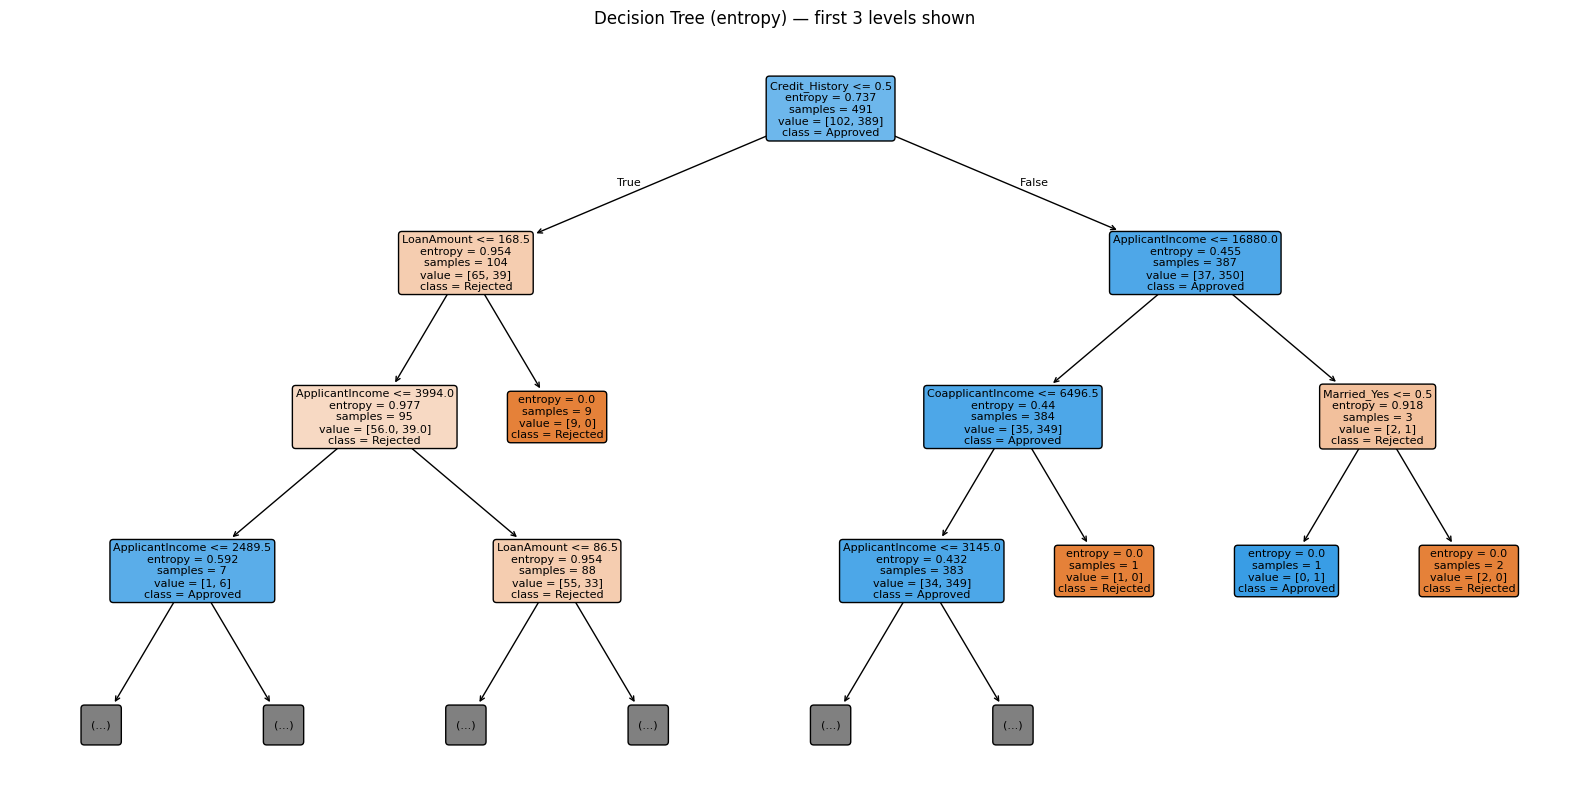

In [49]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(clf_fixed, feature_names=X_train_enc.columns, class_names=['Rejected', 'Approved'],
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title("Decision Tree (entropy) — first 3 levels shown")
plt.show()

In [ ]:
#look at the parameters of DTree classifier
#Look at decision tree regression
#also look at what streamlit
#AWS session
#Random forest - bagging boosting..